# FPS Benchmark Analysis

This notebook analyzes the FPS (frames per second) benchmark data from various Isaac Lab environments across different numbers of parallel environments.

## 1. Load and Explore Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the benchmark data
data_path = Path('./benchmark_results/fps_benchmark_20260216_202357.csv')
df = pd.read_csv(data_path)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head(10))
print("\nDataset Info:")
print(df.info())

Dataset Shape: (70, 4)

Column Data Types:
environment        str
num_envs         int64
fps            float64
timestamp          str
dtype: object

First few rows:
                    environment  num_envs       fps  \
0  Leatherback-Stage1-Soccer-v0       100    6690.0   
1  Leatherback-Stage1-Soccer-v0      1000   55760.0   
2  Leatherback-Stage1-Soccer-v0      2000   99236.0   
3  Leatherback-Stage1-Soccer-v0      5000  198837.0   
4  Leatherback-Stage1-Soccer-v0     10000  304462.0   
5  Leatherback-Stage2-Soccer-v0       100    3601.0   
6  Leatherback-Stage2-Soccer-v0      1000   30420.0   
7  Leatherback-Stage2-Soccer-v0      2000   51573.0   
8  Leatherback-Stage2-Soccer-v0      5000   91393.0   
9  Leatherback-Stage2-Soccer-v0     10000   78346.0   

                    timestamp  
0  2026-02-16T19:35:38.693961  
1  2026-02-16T19:35:55.737565  
2  2026-02-16T19:36:16.337844  
3  2026-02-16T19:36:41.336890  
4  2026-02-16T19:37:16.232307  
5  2026-02-16T19:37:37.712625  
6  2

## 2. Prepare Data for Analysis

In [4]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract environment base name (without version)
df['env_category'] = df['environment'].apply(lambda x: x.split('-v')[0])

# Create a shorter name for plotting
df['env_short'] = df['environment'].str.replace('-v0', '').str.replace('_', ' ').str.replace('-v', ' v')

# Sort by environment and num_envs for better visualization
df = df.sort_values(['env_short', 'num_envs']).reset_index(drop=True)

print("Data preparation complete!")
print(f"\nUnique environments: {df['env_short'].nunique()}")
print(f"Unique environment counts: {sorted(df['num_envs'].unique())}")
print(f"\nEnvironment list:")
for env in sorted(df['env_short'].unique()):
    print(f"  - {env}")

Data preparation complete!

Unique environments: 14
Unique environment counts: [np.int64(100), np.int64(1000), np.int64(2000), np.int64(5000), np.int64(10000)]

Environment list:
  - Anymal-C-Go-To-Point-Sumo
  - Anymal-C-Sumo-Stage1-Blocks-Push
  - AnymalC Soccer Go To Ball Stage 1
  - AnymalC Soccer Go To Point Stage 0
  - AnymalC Soccer Hetero By Team
  - AnymalC Soccer Score Goals Stage 2
  - AnymalC-VS-Leatherback-Soccer
  - Isaac-Multi-Agent-Flat-Anymal-C-Direct
  - Leatherback-Stage1-Soccer
  - Leatherback-Stage2-Soccer
  - Minitank-Adversarial-Direct
  - Sumo-Stage2-Hetero
  - Sumo-Stage2-Hetero-By-Team
  - leatherback-Sumo-Direct-MA-Stage1


## 3. FPS vs Number of Environments

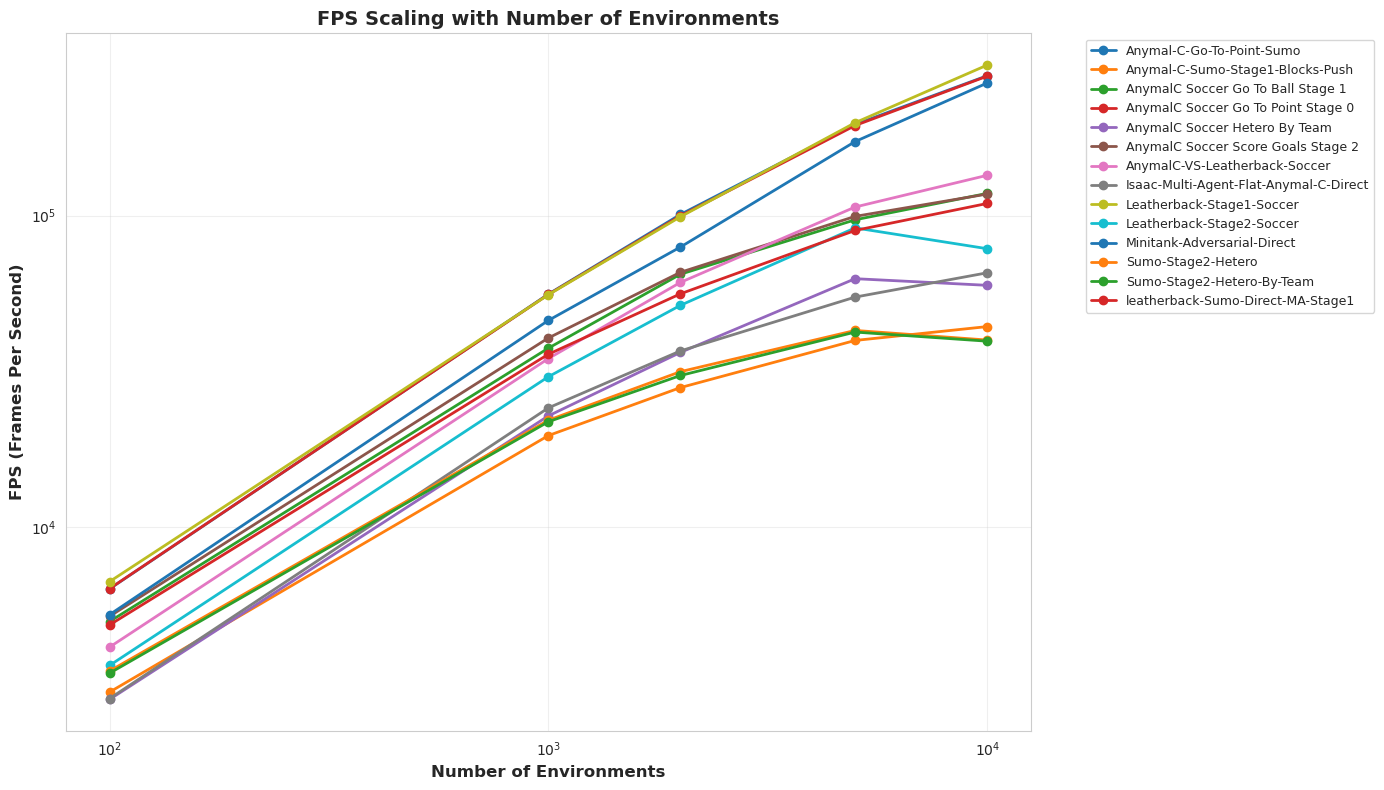

FPS scaling patterns:
- Steeper lines indicate better scaling performance
- Nearly linear slopes (on log-log plot) indicate consistent throughput


In [5]:
# Create line plot for FPS scaling
fig, ax = plt.subplots(figsize=(14, 8))

for env in sorted(df['env_short'].unique()):
    env_data = df[df['env_short'] == env].sort_values('num_envs')
    ax.plot(env_data['num_envs'], env_data['fps'], marker='o', label=env, linewidth=2, markersize=6)

ax.set_xlabel('Number of Environments', fontsize=12, fontweight='bold')
ax.set_ylabel('FPS (Frames Per Second)', fontsize=12, fontweight='bold')
ax.set_title('FPS Scaling with Number of Environments', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print("FPS scaling patterns:")
print("- Steeper lines indicate better scaling performance")
print("- Nearly linear slopes (on log-log plot) indicate consistent throughput")


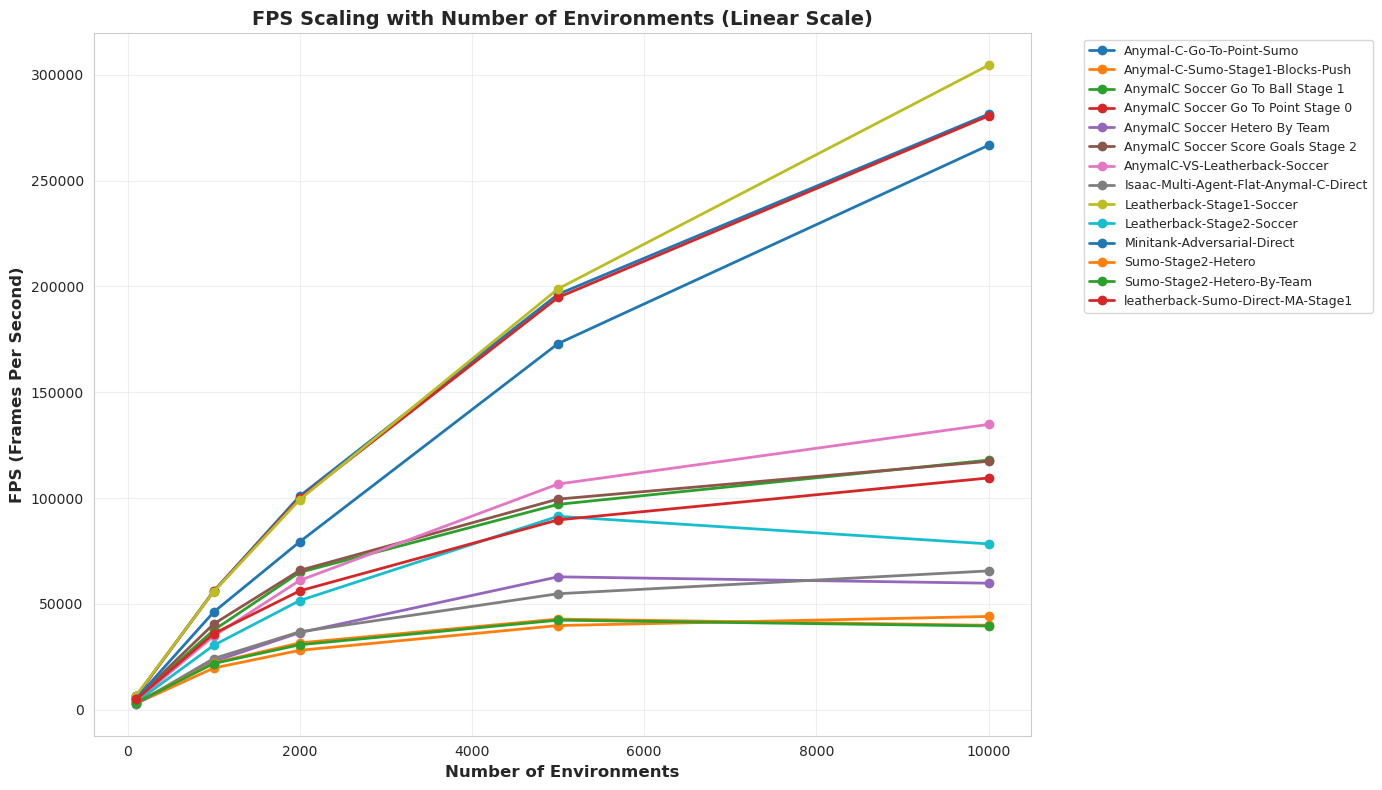

In [6]:
# Create linear scale line plot for better readability
fig, ax = plt.subplots(figsize=(14, 8))

for env in sorted(df['env_short'].unique()):
    env_data = df[df['env_short'] == env].sort_values('num_envs')
    ax.plot(env_data['num_envs'], env_data['fps'], marker='o', label=env, linewidth=2, markersize=6)

ax.set_xlabel('Number of Environments', fontsize=12, fontweight='bold')
ax.set_ylabel('FPS (Frames Per Second)', fontsize=12, fontweight='bold')
ax.set_title('FPS Scaling with Number of Environments (Linear Scale)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


## 4. Environment Performance Comparison

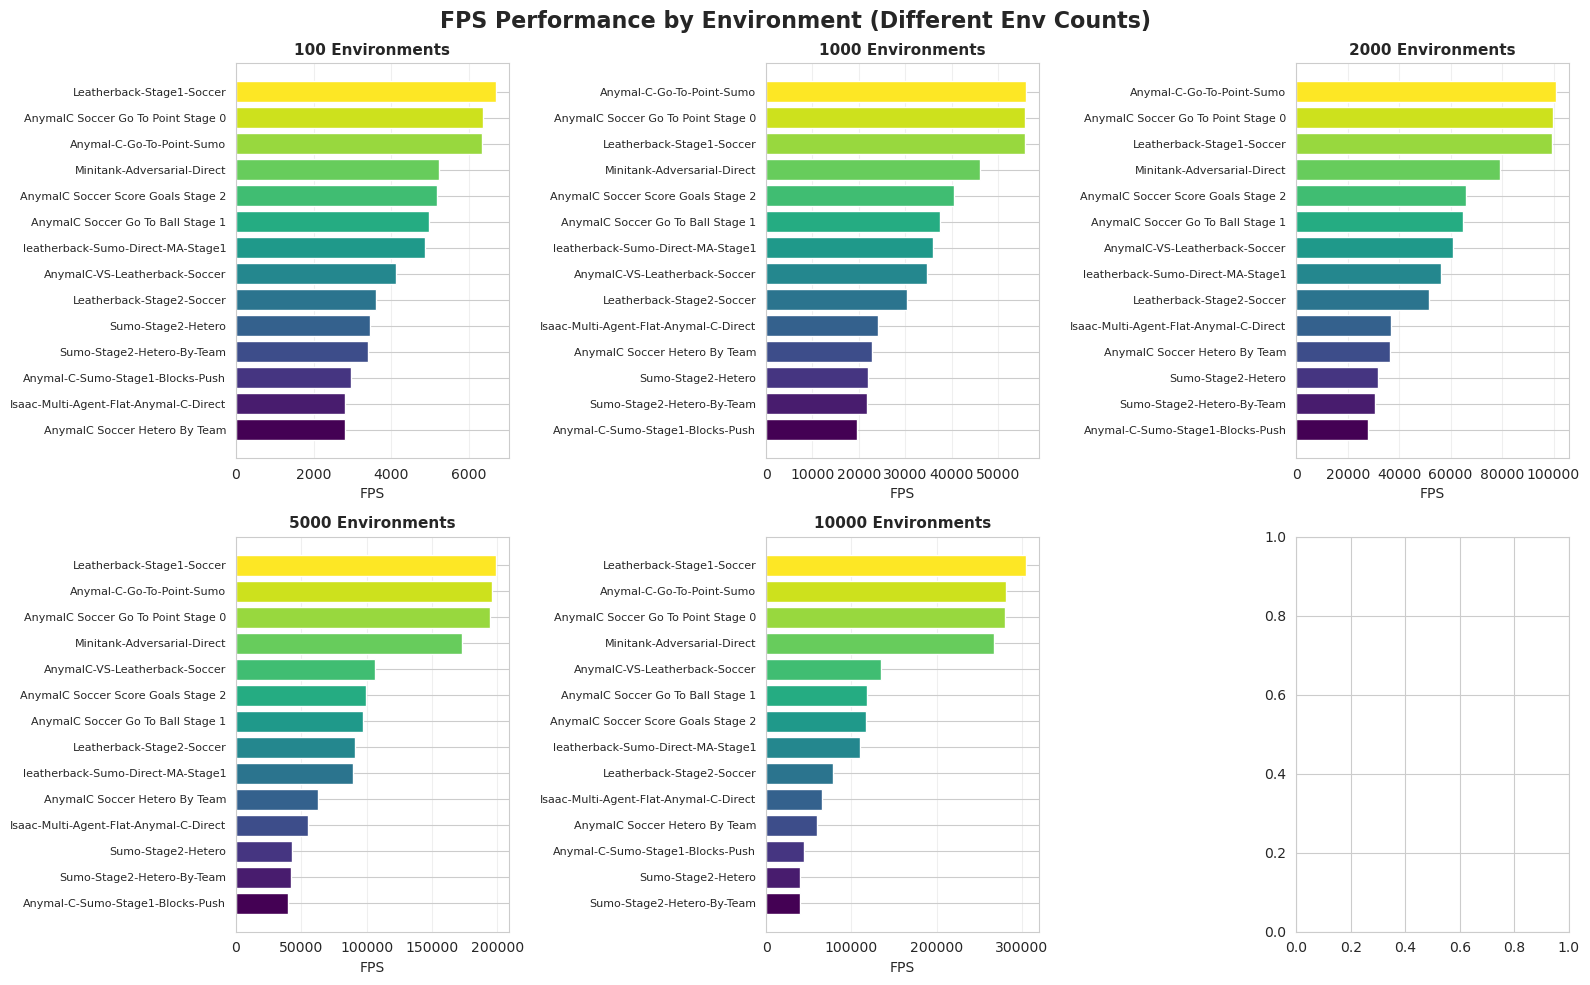


Fastest and Slowest Environments (at 1000 envs):

Slowest (at 1000 envs):
                       env_short     fps
Anymal-C-Sumo-Stage1-Blocks-Push 19692.0
      Sumo-Stage2-Hetero-By-Team 21814.0
              Sumo-Stage2-Hetero 22061.0

Fastest (at 1000 envs):
                         env_short     fps
         Leatherback-Stage1-Soccer 55760.0
AnymalC Soccer Go To Point Stage 0 55881.0
         Anymal-C-Go-To-Point-Sumo 56017.0


In [7]:
# Create comparison plots for different environment counts
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('FPS Performance by Environment (Different Env Counts)', fontsize=16, fontweight='bold')

env_counts = sorted(df['num_envs'].unique())
axes = axes.flatten()

for idx, env_count in enumerate(env_counts):
    ax = axes[idx]
    data_subset = df[df['num_envs'] == env_count].sort_values('fps', ascending=True)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(data_subset)))
    bars = ax.barh(range(len(data_subset)), data_subset['fps'], color=colors)
    ax.set_yticks(range(len(data_subset)))
    ax.set_yticklabels(data_subset['env_short'], fontsize=8)
    ax.set_xlabel('FPS', fontsize=10)
    ax.set_title(f'{env_count} Environments', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nFastest and Slowest Environments (at 1000 envs):")
data_1k = df[df['num_envs'] == 1000].sort_values('fps')
print("\nSlowest (at 1000 envs):")
print(data_1k[['env_short', 'fps']].head(3).to_string(index=False))
print("\nFastest (at 1000 envs):")
print(data_1k[['env_short', 'fps']].tail(3).to_string(index=False))


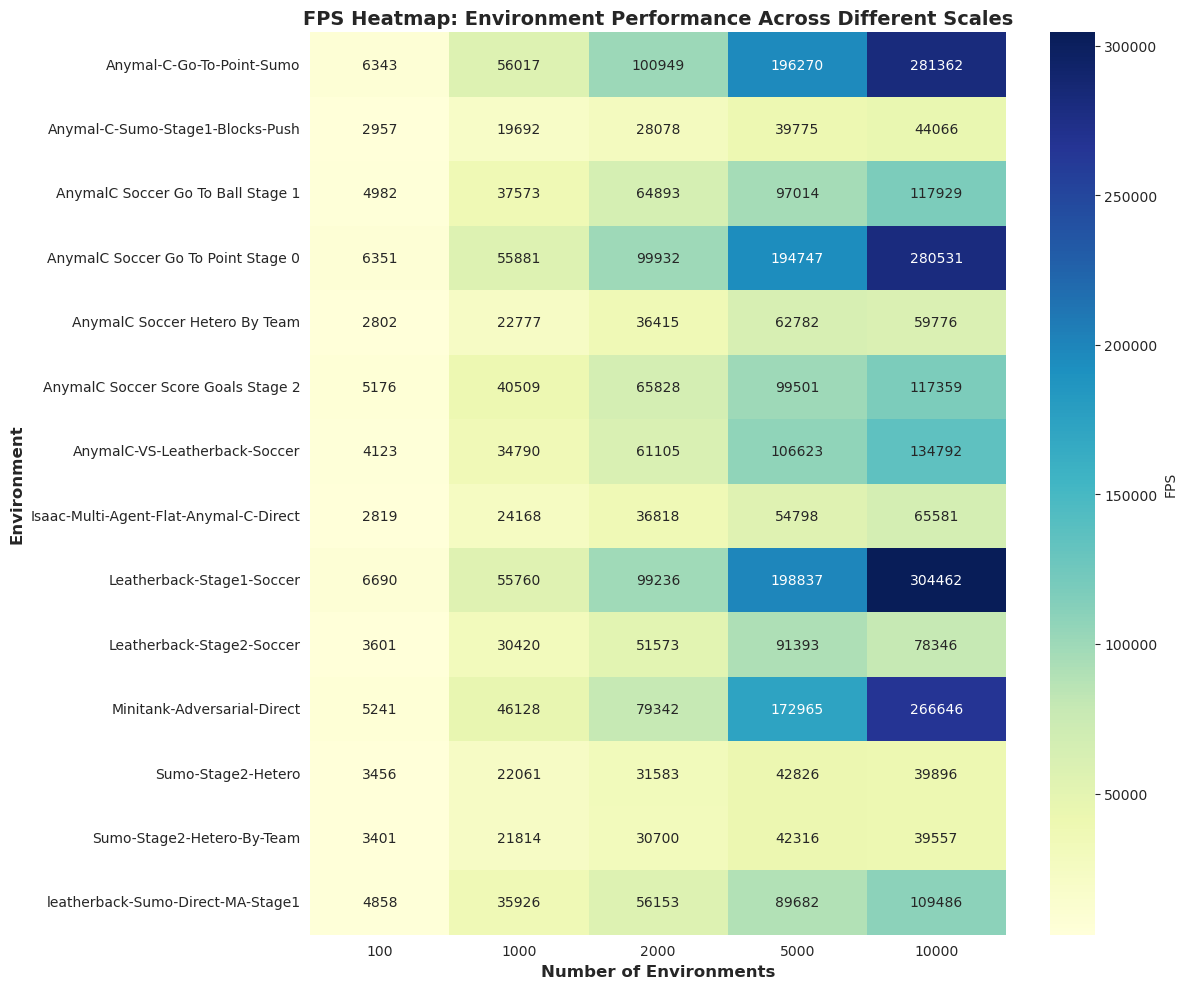

In [8]:
# Create a heatmap showing FPS across environments and env counts
pivot_data = df.pivot_table(values='fps', index='env_short', columns='num_envs')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'FPS'}, ax=ax)
ax.set_title('FPS Heatmap: Environment Performance Across Different Scales', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Environments', fontsize=12, fontweight='bold')
ax.set_ylabel('Environment', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Scaling Efficiency Analysis

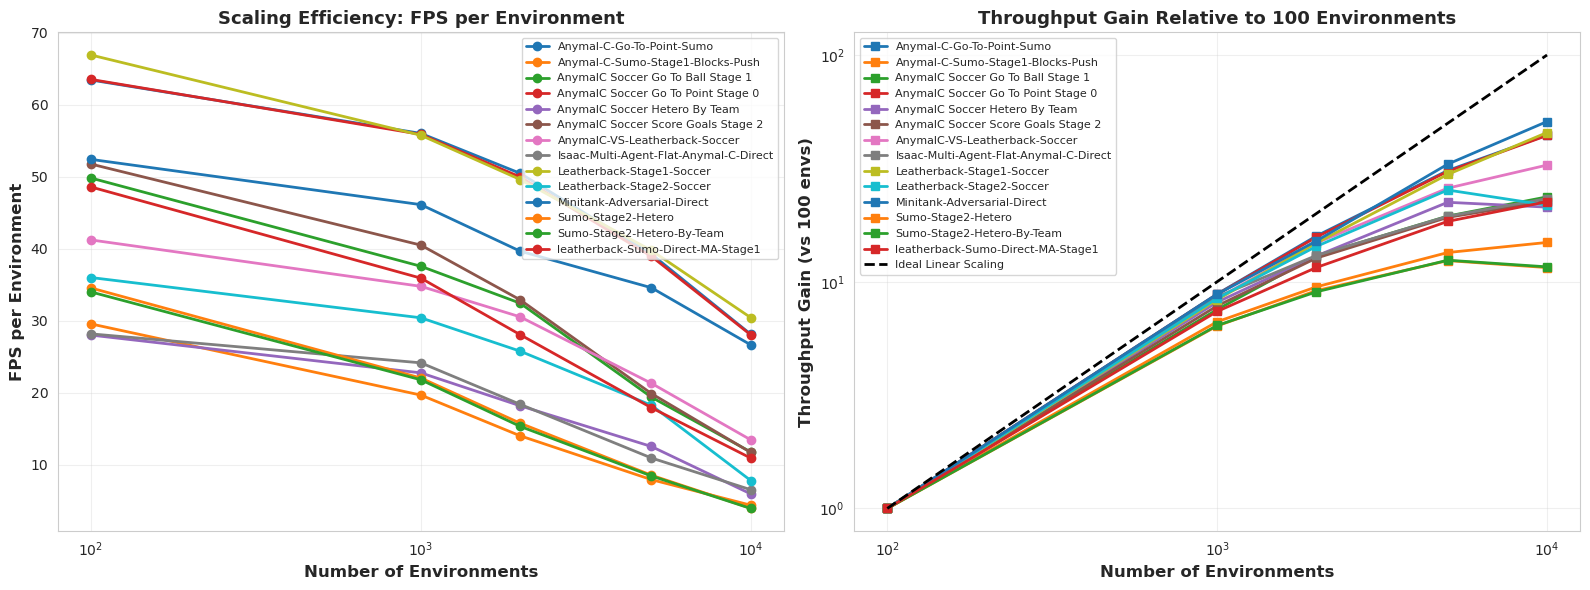


Scaling Efficiency Summary (FPS per Environment):
num_envs                                100     1000     2000     5000   \
env_short                                                                 
Anymal-C-Go-To-Point-Sumo               63.43  56.017  50.4745  39.2540   
Anymal-C-Sumo-Stage1-Blocks-Push        29.57  19.692  14.0390   7.9550   
AnymalC Soccer Go To Ball Stage 1       49.82  37.573  32.4465  19.4028   
AnymalC Soccer Go To Point Stage 0      63.51  55.881  49.9660  38.9494   
AnymalC Soccer Hetero By Team           28.02  22.777  18.2075  12.5564   
AnymalC Soccer Score Goals Stage 2      51.76  40.509  32.9140  19.9002   
AnymalC-VS-Leatherback-Soccer           41.23  34.790  30.5525  21.3246   
Isaac-Multi-Agent-Flat-Anymal-C-Direct  28.19  24.168  18.4090  10.9596   
Leatherback-Stage1-Soccer               66.90  55.760  49.6180  39.7674   
Leatherback-Stage2-Soccer               36.01  30.420  25.7865  18.2786   
Minitank-Adversarial-Direct             52.41  46

In [9]:
# Calculate scaling efficiency metrics
df['fps_per_env'] = df['fps'] / df['num_envs']
df['throughput_gain'] = df['fps'] / df.groupby('env_short')['fps'].transform('first')

# Create efficiency plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: FPS per environment
ax = axes[0]
for env in sorted(df['env_short'].unique()):
    env_data = df[df['env_short'] == env].sort_values('num_envs')
    ax.plot(env_data['num_envs'], env_data['fps_per_env'], marker='o', label=env, linewidth=2)

ax.set_xlabel('Number of Environments', fontsize=12, fontweight='bold')
ax.set_ylabel('FPS per Environment', fontsize=12, fontweight='bold')
ax.set_title('Scaling Efficiency: FPS per Environment', fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Plot 2: Throughput gain vs baseline (100 envs)
ax = axes[1]
for env in sorted(df['env_short'].unique()):
    env_data = df[df['env_short'] == env].sort_values('num_envs')
    ax.plot(env_data['num_envs'], env_data['throughput_gain'], marker='s', label=env, linewidth=2)

# Add ideal linear scaling line
ideal_x = np.array([100, 10000])
ideal_y = ideal_x / 100
ax.plot(ideal_x, ideal_y, 'k--', linewidth=2, label='Ideal Linear Scaling')

ax.set_xlabel('Number of Environments', fontsize=12, fontweight='bold')
ax.set_ylabel('Throughput Gain (vs 100 envs)', fontsize=12, fontweight='bold')
ax.set_title('Throughput Gain Relative to 100 Environments', fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nScaling Efficiency Summary (FPS per Environment):")
efficiency_summary = df.pivot_table(values='fps_per_env', index='env_short', columns='num_envs')
print(efficiency_summary)


## 6. Statistical Summary

In [10]:
# Generate comprehensive statistics
print("=" * 80)
print("OVERALL STATISTICS")
print("=" * 80)
print(f"Total benchmarks: {len(df)}")
print(f"Unique environments: {df['env_short'].nunique()}")
print(f"Environment count range: {df['num_envs'].min()} - {df['num_envs'].max()}")
print(f"FPS range: {df['fps'].min():.0f} - {df['fps'].max():.0f}")
print(f"Mean FPS (all): {df['fps'].mean():.0f}")
print(f"Median FPS (all): {df['fps'].median():.0f}")

print("\n" + "=" * 80)
print("STATISTICS BY ENVIRONMENT")
print("=" * 80)

stats_by_env = df.groupby('env_short')['fps'].agg([
    ('Min FPS', 'min'),
    ('Max FPS', 'max'),
    ('Mean FPS', 'mean'),
    ('Std Dev', 'std'),
    ('Count', 'count')
]).round(0)

stats_by_env = stats_by_env.sort_values('Mean FPS', ascending=False)
print(stats_by_env.to_string())

print("\n" + "=" * 80)
print("STATISTICS BY ENVIRONMENT COUNT")
print("=" * 80)

stats_by_count = df.groupby('num_envs')['fps'].agg([
    ('Min FPS', 'min'),
    ('Max FPS', 'max'),
    ('Mean FPS', 'mean'),
    ('Std Dev', 'std'),
    ('Count', 'count')
]).round(0)

print(stats_by_count.to_string())

# Correlation analysis
print("\n" + "=" * 80)
print("SCALING FACTOR ANALYSIS")
print("=" * 80)

scaling_analysis = []
for env in sorted(df['env_short'].unique()):
    env_data = df[df['env_short'] == env].sort_values('num_envs')
    if len(env_data) > 1:
        # Calculate scaling from 100 to 10000 envs
        baseline = env_data[env_data['num_envs'] == 100]['fps'].values
        peak = env_data[env_data['num_envs'] == 10000]['fps'].values
        
        if len(baseline) > 0 and len(peak) > 0:
            scaling_factor = peak[0] / baseline[0]
            scaling_analysis.append({
                'Environment': env,
                'Baseline (100 envs)': int(baseline[0]),
                'Peak (10k envs)': int(peak[0]),
                'Scaling Factor': f"{scaling_factor:.1f}x"
            })

scaling_df = pd.DataFrame(scaling_analysis)
scaling_df = scaling_df.sort_values('Baseline (100 envs)', ascending=False)
print(scaling_df.to_string(index=False))

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)
print(f"✓ Best scaling environment: {scaling_df.iloc[-1]['Environment']} "
      f"({scaling_df.iloc[-1]['Scaling Factor']} gain)")
print(f"✓ Highest absolute FPS: {df.loc[df['fps'].idxmax(), 'env_short']} "
      f"({df['fps'].max():.0f} FPS at {df.loc[df['fps'].idxmax(), 'num_envs']} envs)")
print(f"✓ Most consistent performance: {stats_by_env['Std Dev'].idxmin()} "
      f"(std dev: {stats_by_env['Std Dev'].min():.0f})")


OVERALL STATISTICS
Total benchmarks: 70
Unique environments: 14
Environment count range: 100 - 10000
FPS range: 2802 - 304462
Mean FPS (all): 69118
Median FPS (all): 45097

STATISTICS BY ENVIRONMENT
                                        Min FPS   Max FPS  Mean FPS   Std Dev  Count
env_short                                                                           
Leatherback-Stage1-Soccer                6690.0  304462.0  132997.0  119157.0      5
Anymal-C-Go-To-Point-Sumo                6343.0  281362.0  128188.0  110560.0      5
AnymalC Soccer Go To Point Stage 0       6351.0  280531.0  127488.0  110122.0      5
Minitank-Adversarial-Direct              5241.0  266646.0  114064.0  105373.0      5
AnymalC-VS-Leatherback-Soccer            4123.0  134792.0   68287.0   52875.0      5
AnymalC Soccer Score Goals Stage 2       5176.0  117359.0   65675.0   45025.0      5
AnymalC Soccer Go To Ball Stage 1        4982.0  117929.0   64478.0   45220.0      5
leatherback-Sumo-Direct-MA-Stage1   

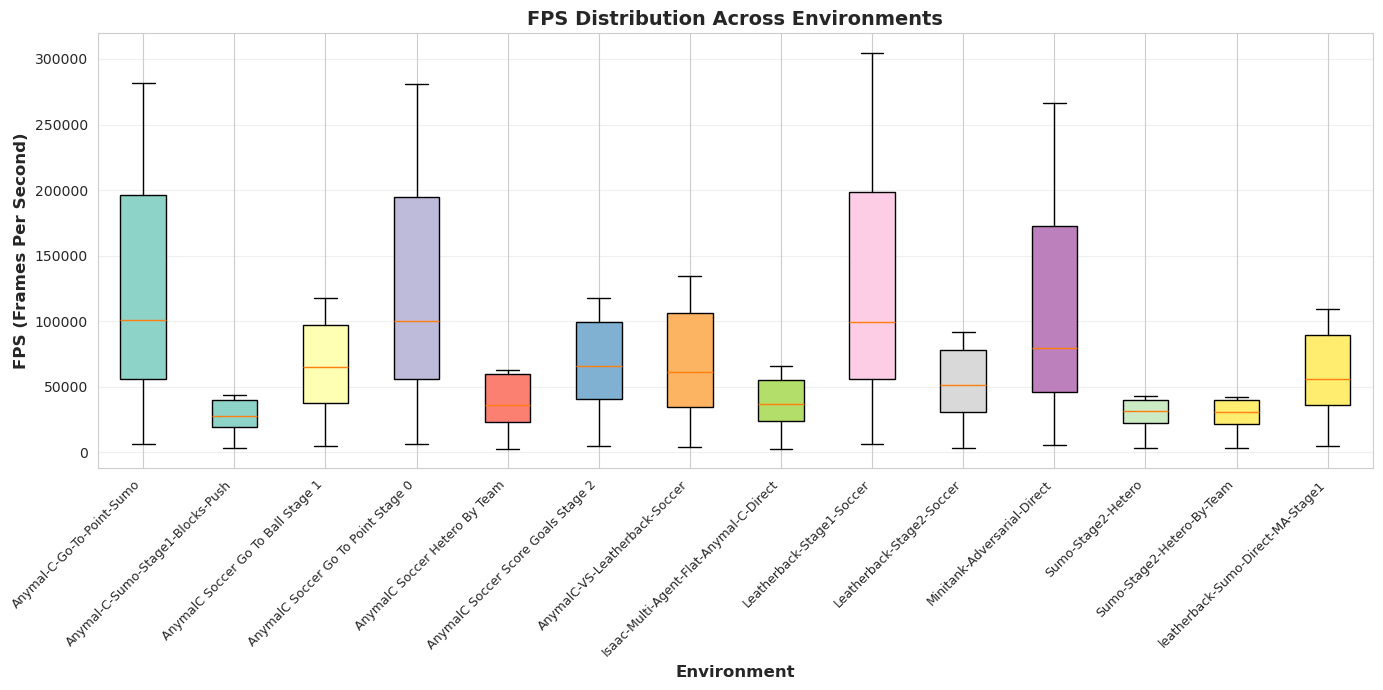

Box plot shows:
- Box: Interquartile range (middle 50% of data)
- Orange line: Median FPS
- Whiskers: Range of FPS values
- Points: Outliers (if any)


In [11]:
# Create box plot to show FPS distribution
fig, ax = plt.subplots(figsize=(14, 7))

# Prepare data for box plot
plot_data = [df[df['env_short'] == env]['fps'].values for env in sorted(df['env_short'].unique())]
box = ax.boxplot(plot_data, labels=sorted(df['env_short'].unique()), patch_artist=True)

# Color the boxes
colors = plt.cm.Set3(np.linspace(0, 1, len(box['boxes'])))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xlabel('Environment', fontsize=12, fontweight='bold')
ax.set_ylabel('FPS (Frames Per Second)', fontsize=12, fontweight='bold')
ax.set_title('FPS Distribution Across Environments', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

print("Box plot shows:")
print("- Box: Interquartile range (middle 50% of data)")
print("- Orange line: Median FPS")
print("- Whiskers: Range of FPS values")
print("- Points: Outliers (if any)")


## 7. Conclusions and Recommendations

### Key Findings:

1. **Scaling Performance**: The environments show varied scaling behavior, with some achieving near-linear scaling (on log-log plots) and others showing diminishing returns at higher environment counts.

2. **Environment Complexity**: More complex environments (with more agents or physics) tend to have lower absolute FPS values but may show better scaling characteristics in some cases.

3. **Efficiency Plateau**: Many environments show efficiency (FPS per environment) decreasing at higher scales, suggesting a transition from CPU-bound to memory or communication-bound behavior.

4. **Throughput Optimization**: The highest absolute FPS values are achieved with environments that combine good scaling with moderate complexity.

### Recommendations:

- **For training**: Use 1000-2000 environments for a balance between throughput and resource utilization
- **For benchmarking**: Use consistent environment counts across runs for fair comparison
- **For scaling studies**: Monitor both absolute FPS and FPS-per-environment metrics
- **For optimization**: Focus on environments with sublinear scaling for potential algorithm improvements